## Setup and Data Loading

### Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')
# Set plot style
# sns.set(style="whitegrid")

## Data


In [3]:
# Load the dataset
df1 = pd.read_csv('telecom/Client.csv')
df2 = pd.read_csv("telecom/Record.csv")

df = pd.merge(df1 , df2, on='Customer_ID')


print(" dataset:")
df.head()

 dataset:


,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,...,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months
0,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,...,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61
1,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,...,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56
2,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,...,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58
3,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,...,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60
4,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,...,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57


# Exploratory Data Analysis (EDA)

In [4]:
df = df.drop('Customer_ID', axis=1)

In [5]:
corr_all = df.select_dtypes(include='number').corr()['churn'].abs().sort_values(ascending=False)
print(corr_all.head(20))

churn            1.000000
eqpdays          0.112691
hnd_price        0.103184
totmrc_Mean      0.068558
mou_Mean         0.057027
mou_cvce_Mean    0.052042
complete_Mean    0.051740
comp_vce_Mean    0.051574
avg3mou          0.049546
mou_opkv_Mean    0.048896
attempt_Mean     0.048533
plcd_vce_Mean    0.048321
peak_vce_Mean    0.048320
opk_vce_Mean     0.047873
mou_peav_Mean    0.047287
mou_rvce_Mean    0.047148
models           0.045065
lor              0.044713
avg6mou          0.044060
avg3qty          0.043883
Name: churn, dtype: float64


## using Important Features

In [6]:
use_features = ['uniqsubs', 'actvsubs', 'new_cell', 'crclscod', 'asl_flag', 'totcalls','totmou', 'totrev', 'adjrev', 'adjmou', 'adjqty',
                'avgrev', 'avgmou','avgqty','churn','eqpdays', 'hnd_price', 'totmrc_Mean', 'mou_Mean', 'mou_cvce_Mean', 'complete_Mean',
                'comp_vce_Mean', 'avg3mou', 'mou_opkv_Mean', 'attempt_Mean', 'plcd_vce_Mean', 'peak_vce_Mean', 'opk_vce_Mean', 'mou_peav_Mean', 'mou_rvce_Mean']

In [7]:
df = df[use_features]
df['crclscod']

0         A
1        EA
2         C
3         B
4         A
         ..
99995     B
99996    CY
99997    DA
99998    EA
99999     B
Name: crclscod, Length: 100000, dtype: str

In [8]:
df.describe()

,uniqsubs,actvsubs,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,...,complete_Mean,comp_vce_Mean,avg3mou,mou_opkv_Mean,attempt_Mean,plcd_vce_Mean,peak_vce_Mean,opk_vce_Mean,mou_peav_Mean,mou_rvce_Mean
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.548140,1.358960,2877.141930,7648.363833,1031.924988,960.111528,7546.314699,2836.366920,57.913832,483.726493,...,109.666977,108.892535,519.641210,165.280703,145.752225,144.881677,88.480285,66.003498,174.080788,111.654562
std,1.075255,0.655555,3790.863474,8666.558293,852.907511,840.170815,8594.889729,3756.513882,36.161292,438.485213,...,119.594305,118.580079,533.634073,237.332918,159.348094,158.267711,103.066103,91.456885,207.673553,162.691285
min,1.000000,0.000000,0.000000,0.000000,3.650000,2.400000,0.000000,0.000000,0.480000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,889.000000,2529.000000,518.980000,452.180000,2474.000000,868.000000,35.370000,176.140000,...,28.666667,28.666667,152.000000,18.536667,38.333333,38.333333,21.666667,10.333333,37.642500,7.650000
50%,1.000000,1.000000,1822.000000,5191.500000,804.530000,737.760000,5102.500000,1789.000000,49.890000,360.190000,...,76.000000,75.666667,358.000000,75.841667,101.000000,100.333333,60.333333,34.333333,115.366667,50.200000
75%,2.000000,2.000000,3492.000000,9776.000000,1263.767500,1188.175000,9661.000000,3442.000000,69.480000,655.670000,...,150.666667,149.666667,711.000000,211.195000,199.666667,198.666667,118.666667,86.333333,233.223333,149.452500
max,196.000000,53.000000,98874.000000,233419.096700,27321.500000,27071.300000,232855.100000,98705.000000,924.270000,7040.130000,...,1894.333333,1894.333333,7716.000000,4337.893333,2289.000000,2289.000000,2090.666667,1643.333333,4015.346667,3287.250000


In [9]:
print(df.isnull().sum().to_string())

uniqsubs           0
actvsubs           0
new_cell           0
crclscod           0
asl_flag           0
totcalls           0
totmou             0
totrev             0
adjrev             0
adjmou             0
adjqty             0
avgrev             0
avgmou             0
avgqty             0
churn              0
eqpdays            1
hnd_price        847
totmrc_Mean      357
mou_Mean         357
mou_cvce_Mean      0
complete_Mean      0
comp_vce_Mean      0
avg3mou            0
mou_opkv_Mean      0
attempt_Mean       0
plcd_vce_Mean      0
peak_vce_Mean      0
opk_vce_Mean       0
mou_peav_Mean      0
mou_rvce_Mean      0


In [10]:

df.select_dtypes(include='number').corr()

,uniqsubs,actvsubs,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,...,complete_Mean,comp_vce_Mean,avg3mou,mou_opkv_Mean,attempt_Mean,plcd_vce_Mean,peak_vce_Mean,opk_vce_Mean,mou_peav_Mean,mou_rvce_Mean
uniqsubs,1.000000,0.774229,0.022994,0.007589,0.011241,0.008911,0.004428,0.020395,-0.017016,-0.028268,...,-0.018578,-0.018131,-0.024451,-0.048860,-0.020571,-0.020162,0.009795,-0.032897,0.000551,-0.017002
actvsubs,0.774229,1.000000,0.009558,-0.016039,-0.002104,-0.003066,-0.017946,0.007781,-0.054763,-0.069729,...,-0.043621,-0.042739,-0.058065,-0.085768,-0.046474,-0.045727,-0.003651,-0.058348,-0.021408,-0.040794
totcalls,0.022994,0.009558,1.000000,0.925686,0.771885,0.771358,0.925415,0.999798,0.516714,0.595474,...,0.572718,0.574133,0.549959,0.305430,0.554466,0.555379,0.647038,0.482349,0.538766,0.503992
totmou,0.007589,-0.016039,0.925686,1.000000,0.837359,0.835544,0.999747,0.925616,0.623127,0.721636,...,0.591941,0.592740,0.673692,0.450326,0.573989,0.574400,0.635094,0.475557,0.646077,0.581244
totrev,0.011241,-0.002104,0.771885,0.837359,1.000000,0.998492,0.836831,0.771464,0.683362,0.459262,...,0.403613,0.403691,0.440811,0.203631,0.382033,0.381874,0.492155,0.245309,0.527218,0.391014
adjrev,0.008911,-0.003066,0.771358,0.835544,0.998492,1.000000,0.835433,0.771261,0.675115,0.450469,...,0.398909,0.399048,0.435267,0.199788,0.377398,0.377290,0.487928,0.241665,0.522393,0.387266
adjmou,0.004428,-0.017946,0.925415,0.999747,0.836831,0.835433,1.000000,0.925759,0.622101,0.720841,...,0.591773,0.592576,0.673897,0.450785,0.573811,0.574225,0.634972,0.475663,0.645957,0.581591
adjqty,0.020395,0.007781,0.999798,0.925616,0.771464,0.771261,0.925759,1.000000,0.516008,0.595057,...,0.572614,0.574031,0.550206,0.305745,0.554346,0.555260,0.647031,0.482394,0.538802,0.504243
avgrev,-0.017016,-0.054763,0.516714,0.623127,0.683362,0.675115,0.622101,0.516008,1.000000,0.762748,...,0.593449,0.591177,0.679508,0.420110,0.582738,0.580598,0.620022,0.454553,0.666603,0.564772
avgmou,-0.028268,-0.069729,0.595474,0.721636,0.459262,0.450469,0.720841,0.595057,0.762748,1.000000,...,0.750190,0.749115,0.888626,0.708912,0.746383,0.745246,0.694773,0.693099,0.715040,0.726249


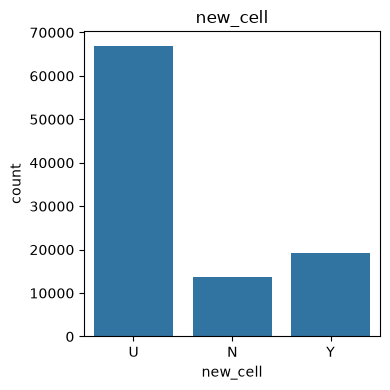

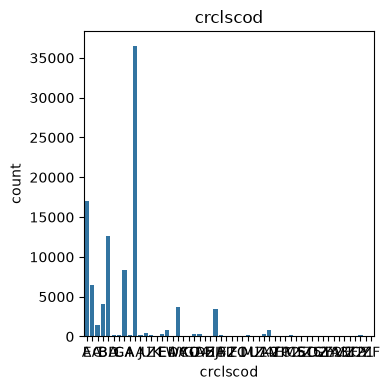

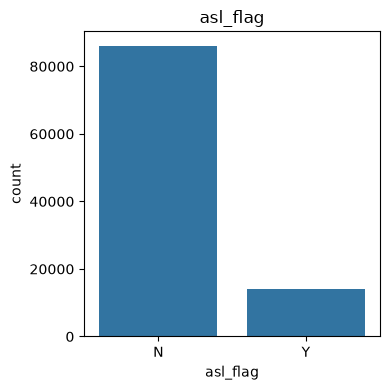

In [11]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
numerical_cols = df.select_dtypes(include=['number']).columns

# Plot categorical columns with countplot
for col in categorical_cols:
    plt.figure(figsize=(4, 4))
    sns.countplot(x=df[col])
    plt.title(col)
    plt.tight_layout()
    plt.show()




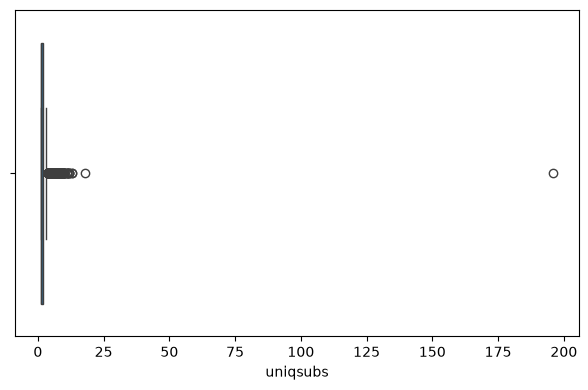

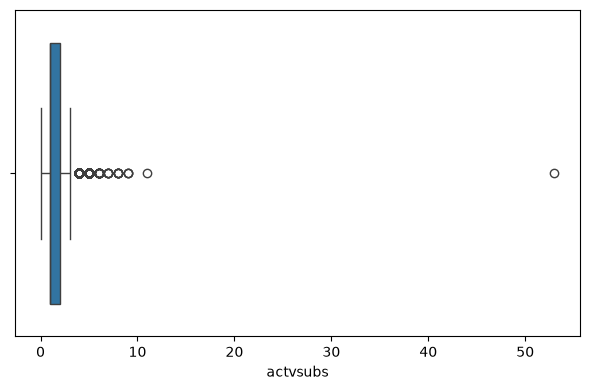

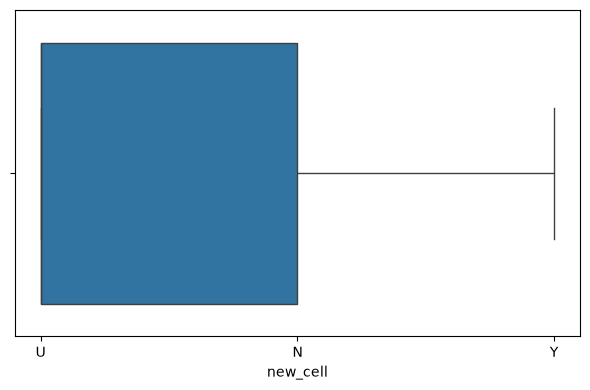

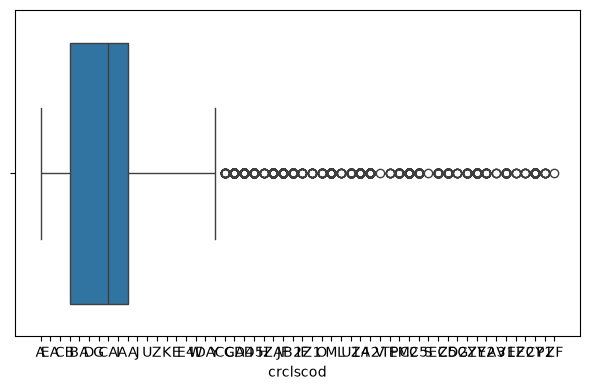

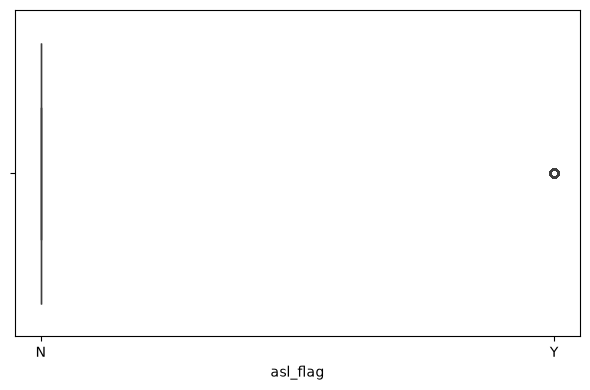

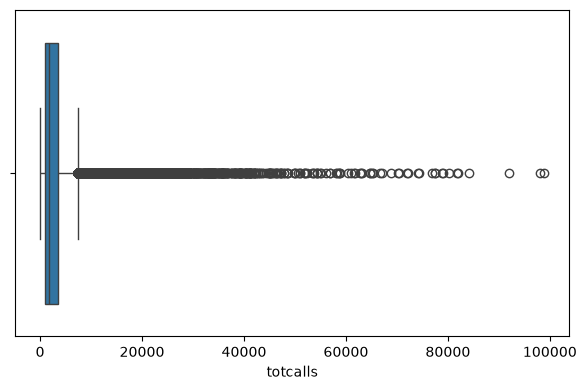

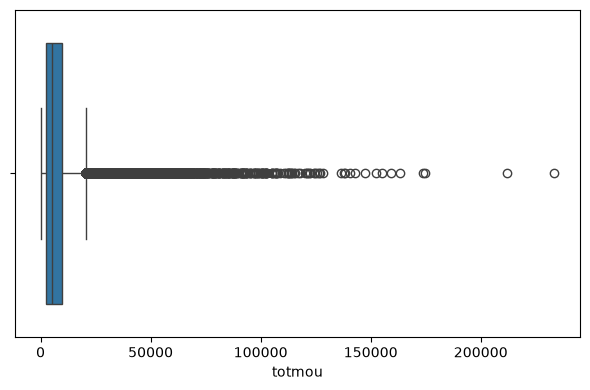

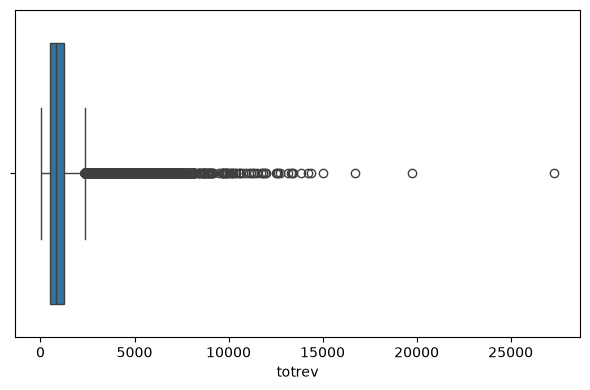

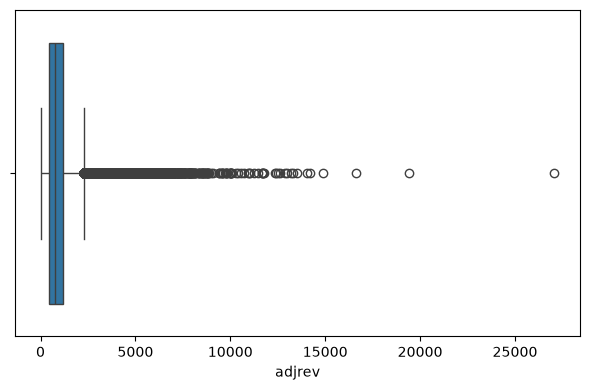

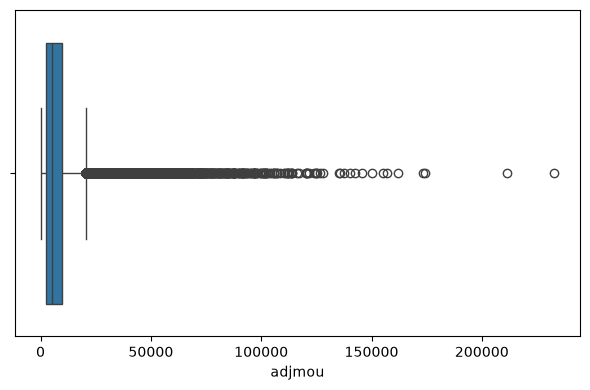

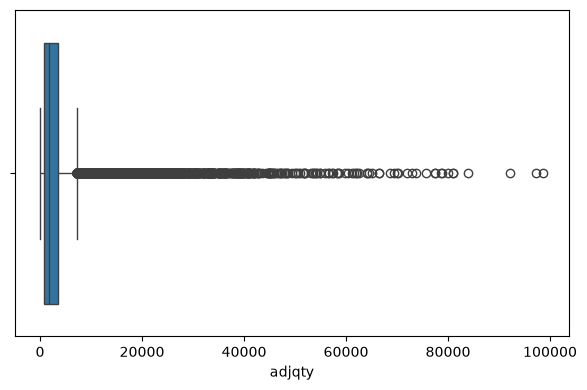

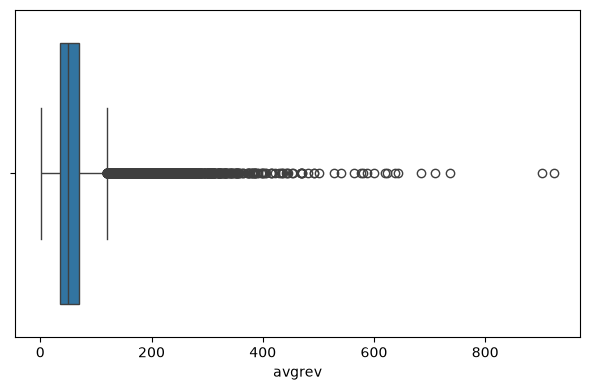

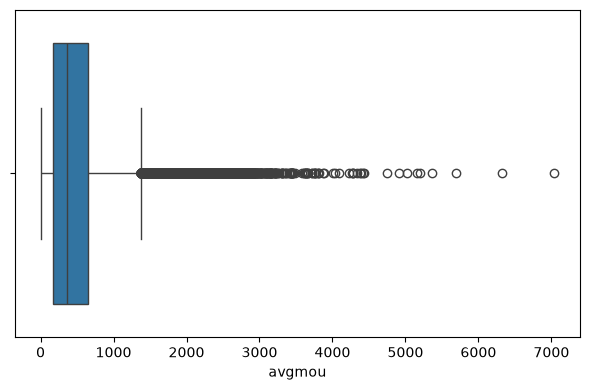

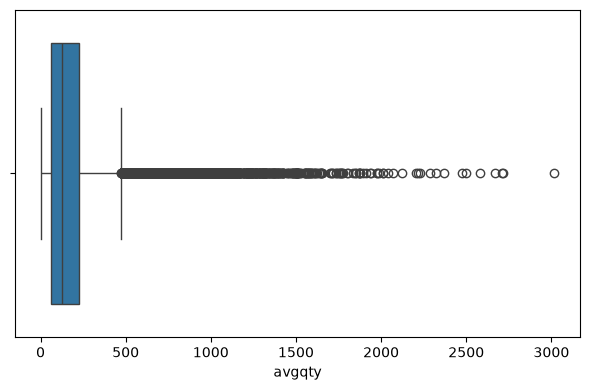

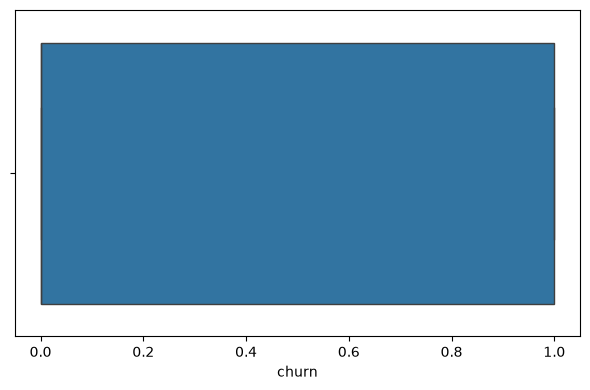

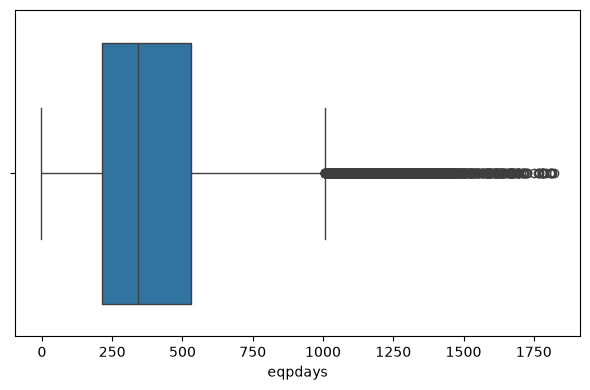

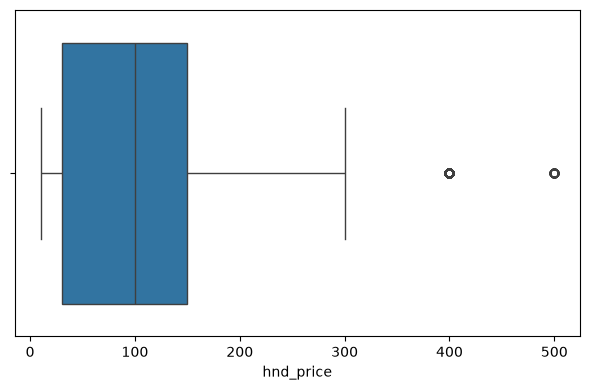

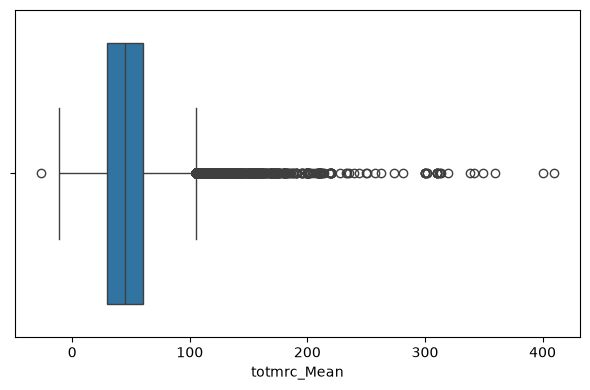

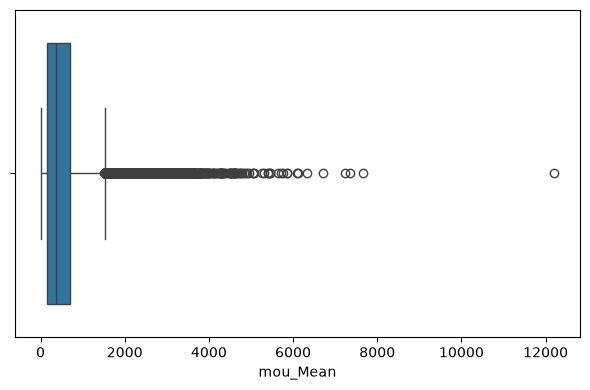

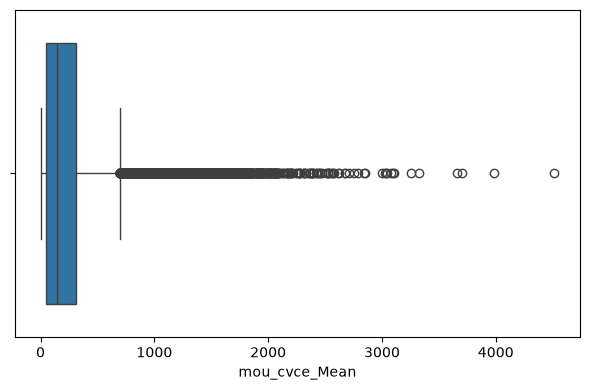

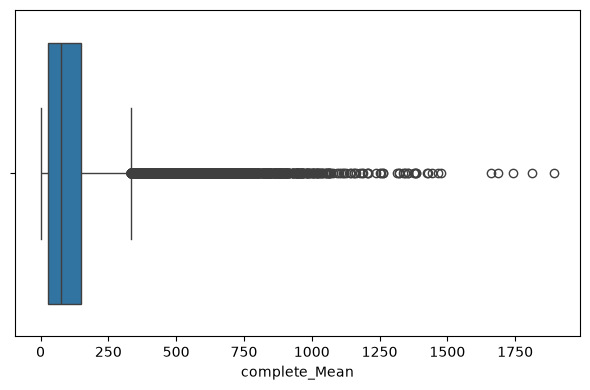

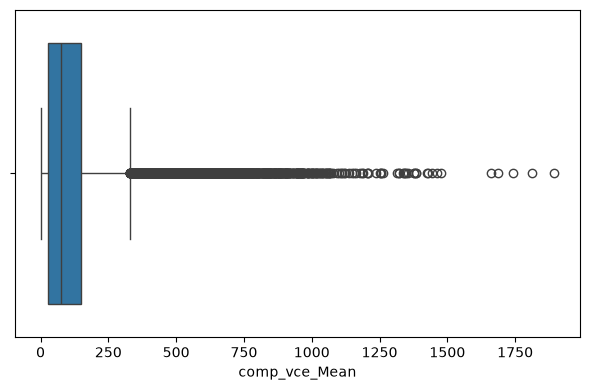

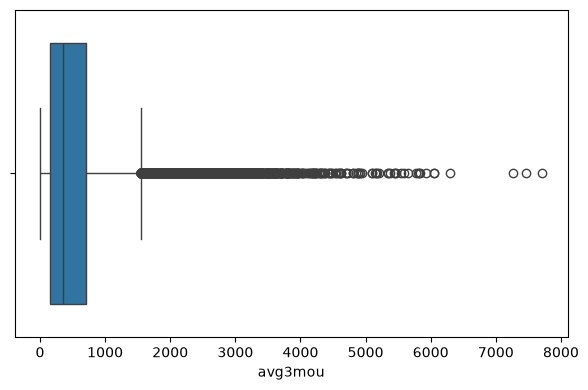

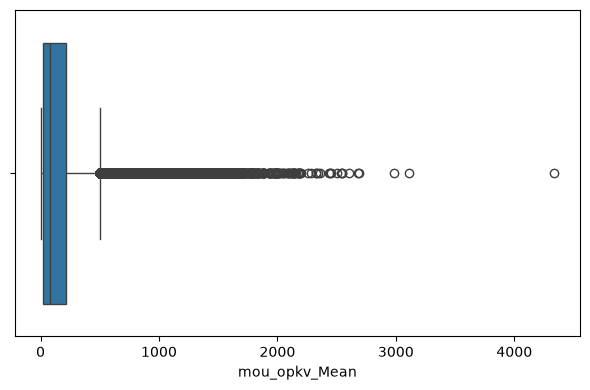

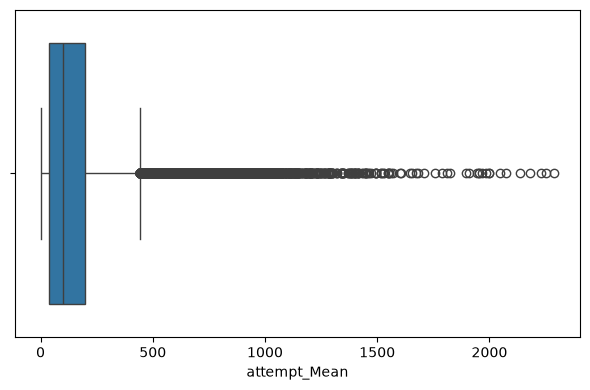

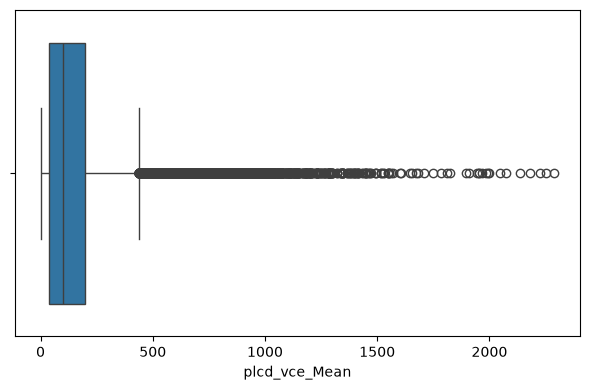

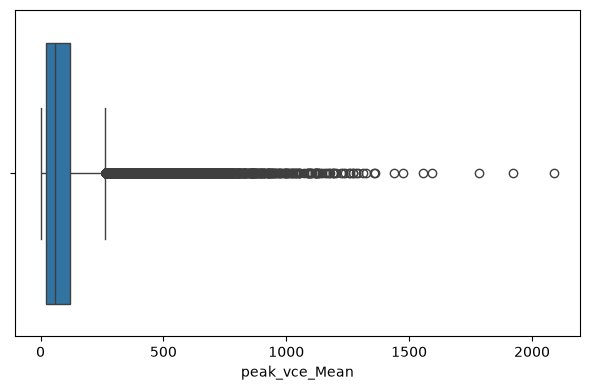

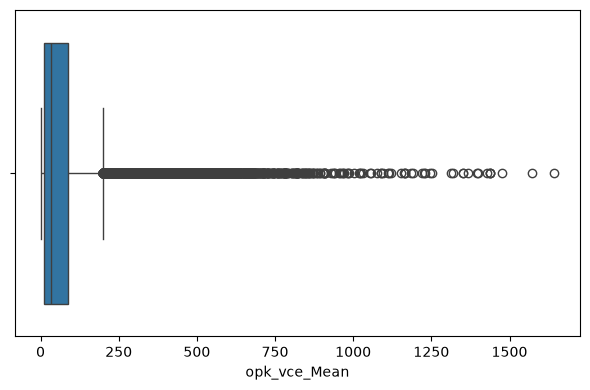

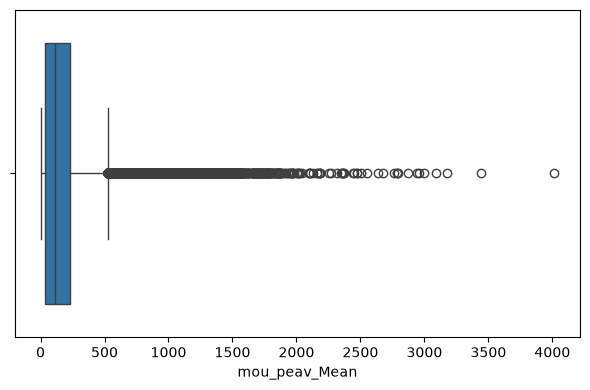

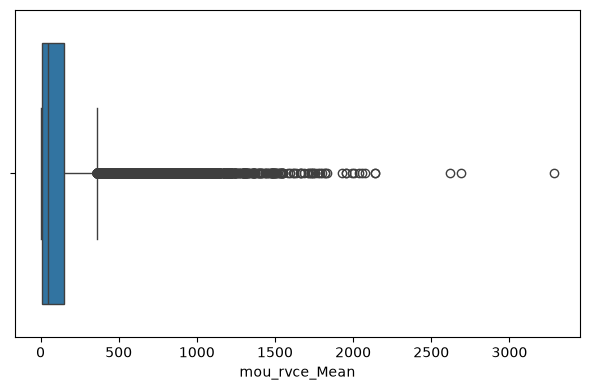

In [12]:
for  col in df:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.tight_layout()

In [13]:
def plot_boxplot(data):
    plt.figure(figsize = (4,4))
    sns.boxplot(x = data)
    plt.tight_layout()

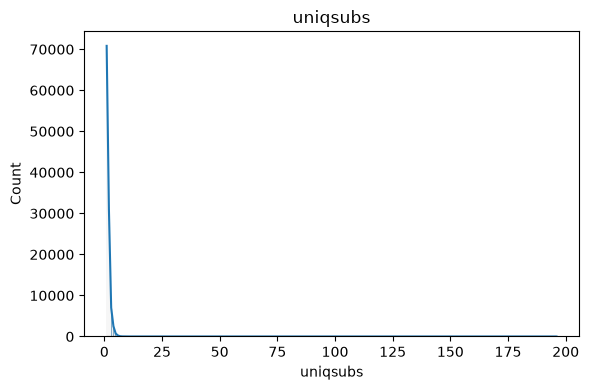

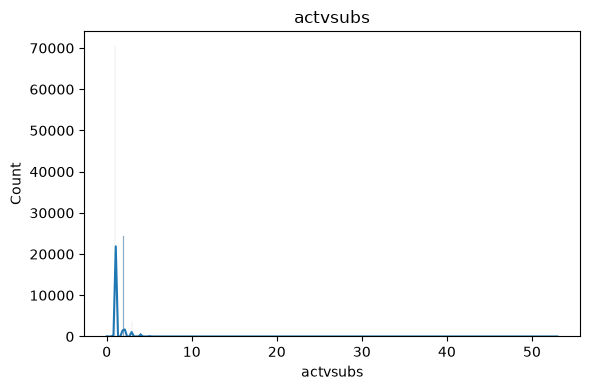

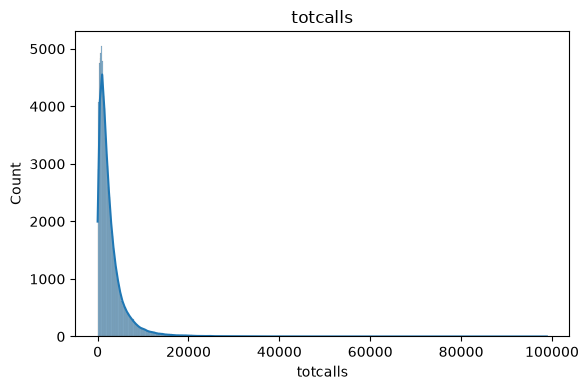

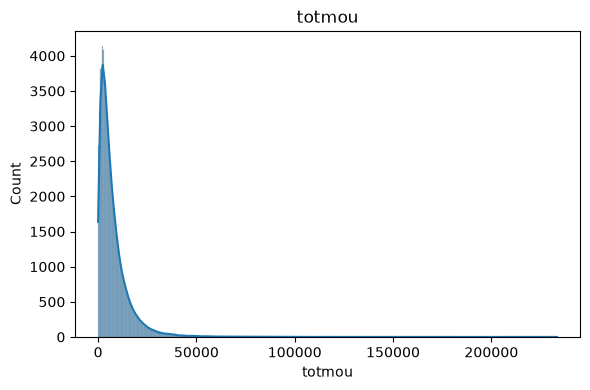

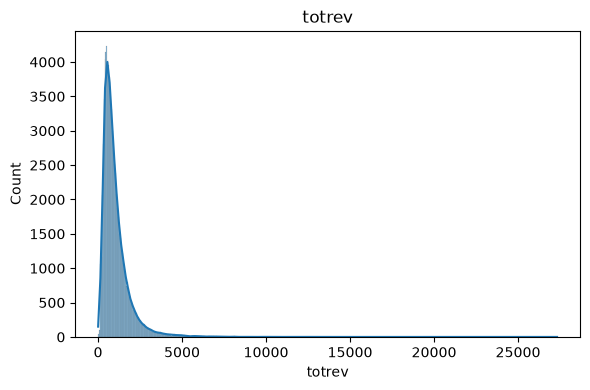

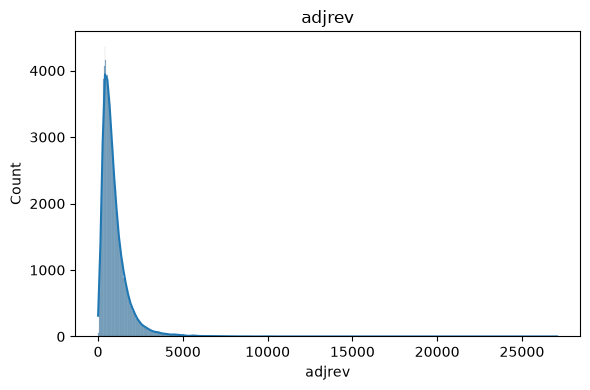

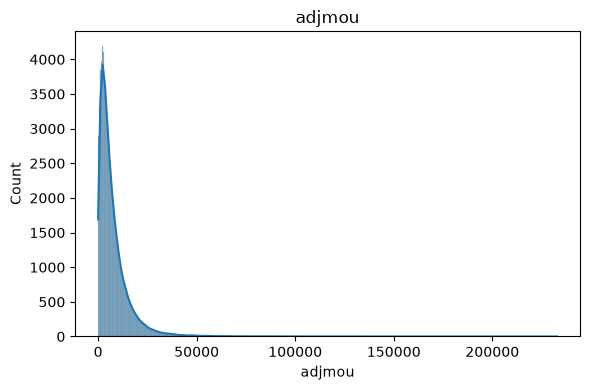

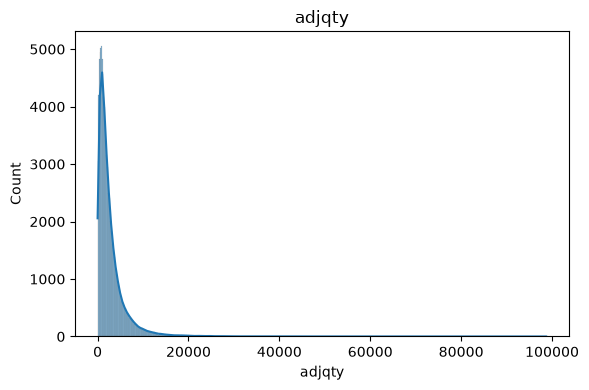

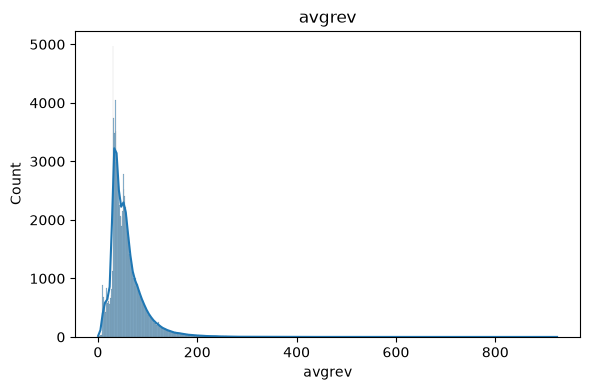

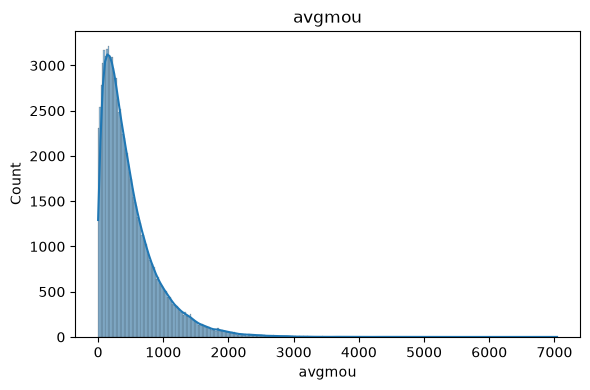

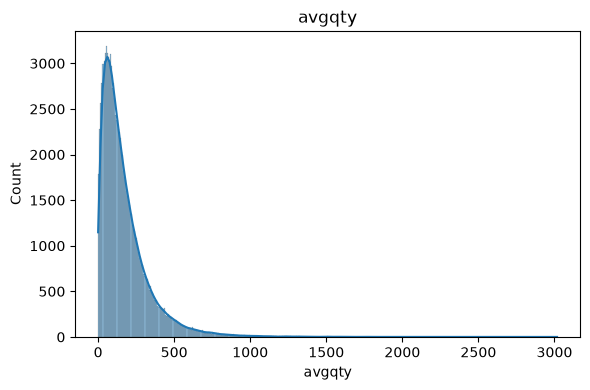

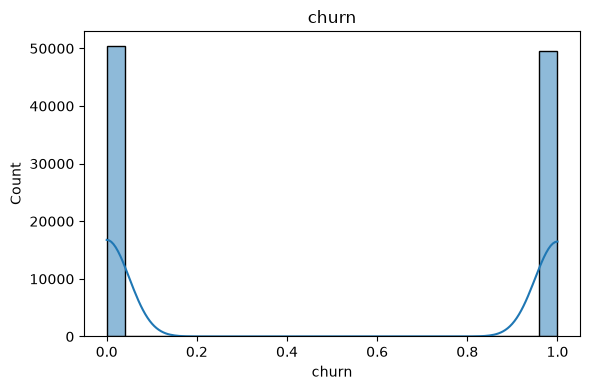

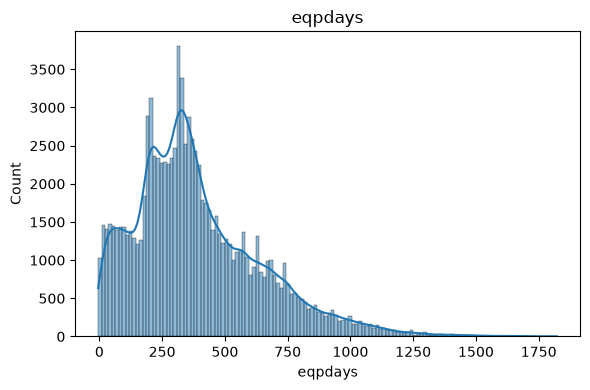

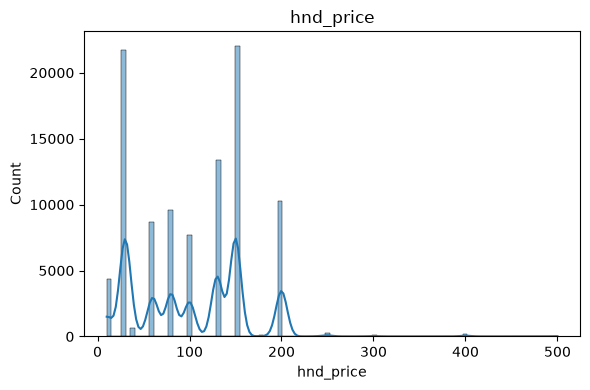

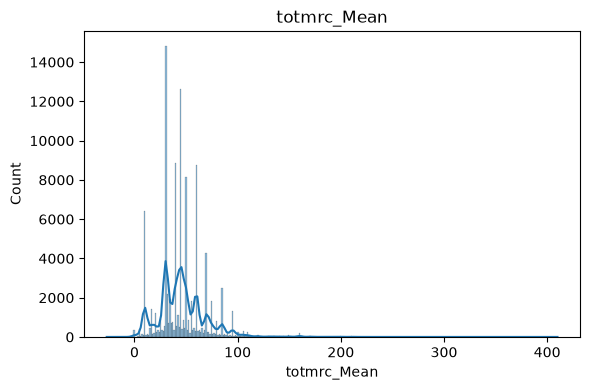

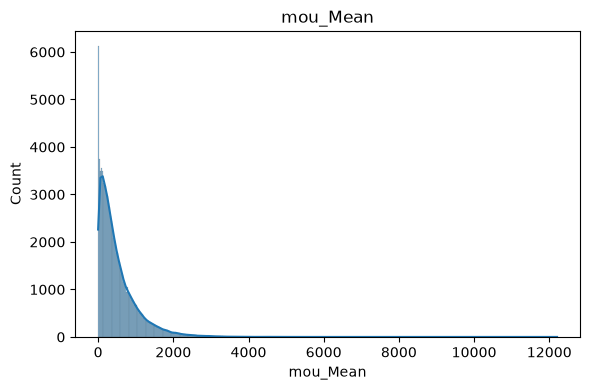

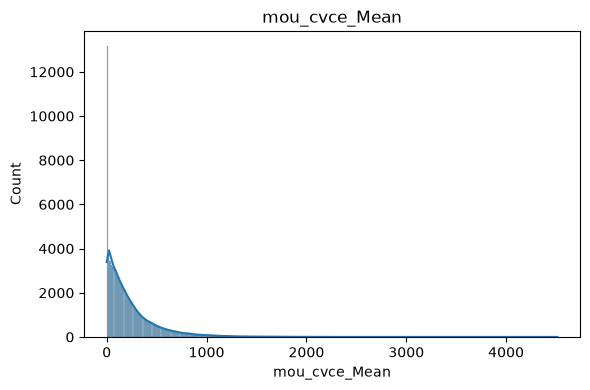

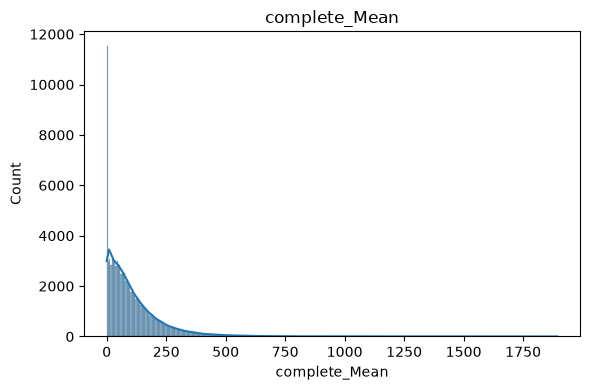

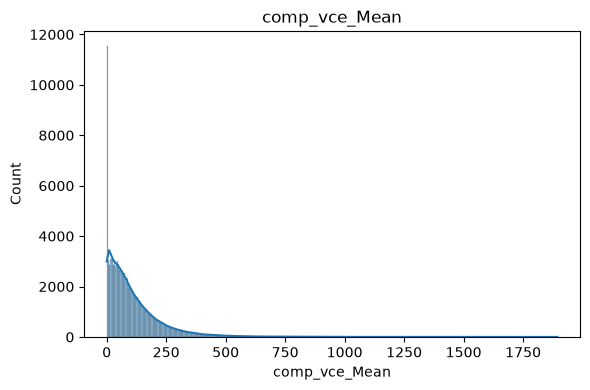

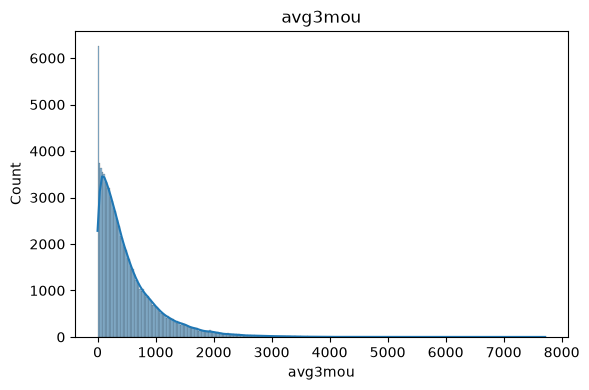

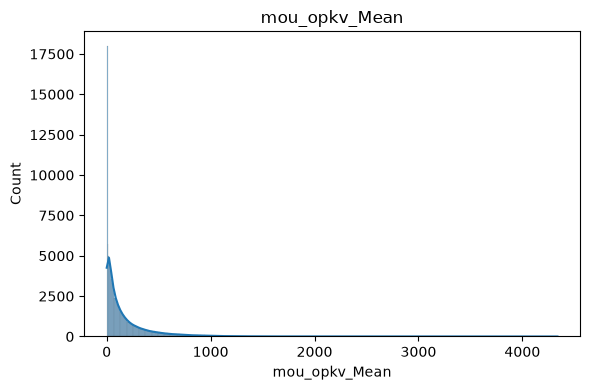

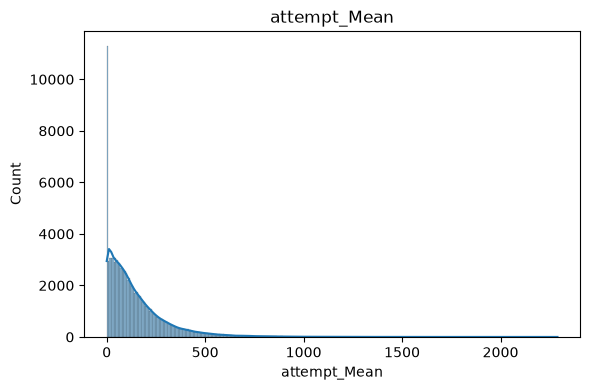

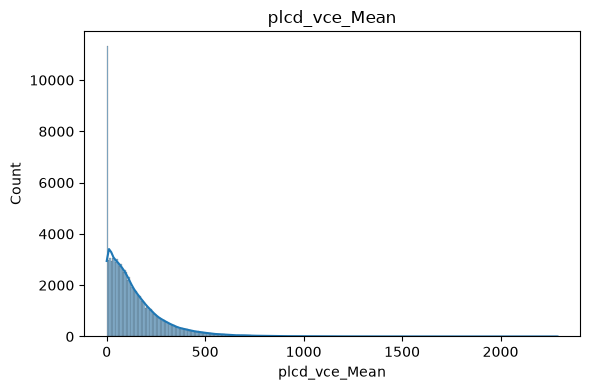

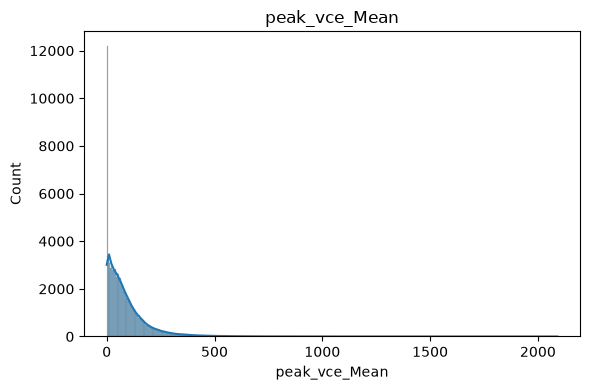

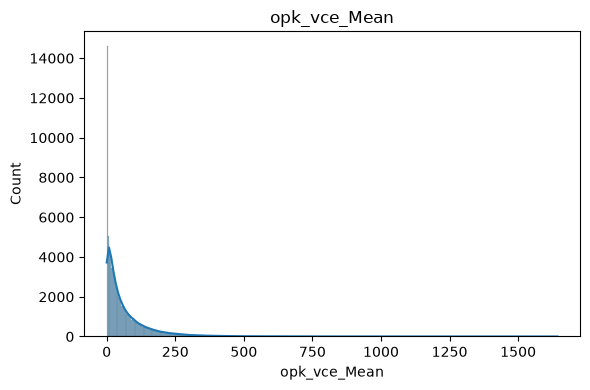

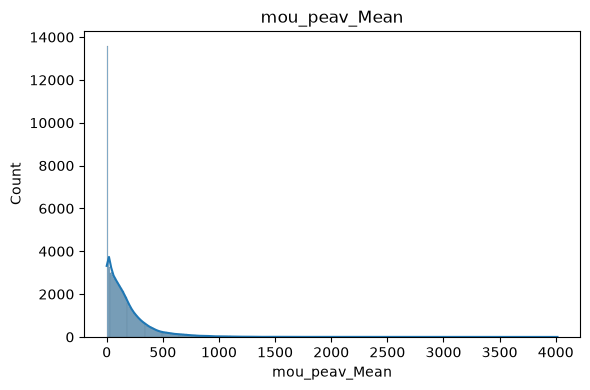

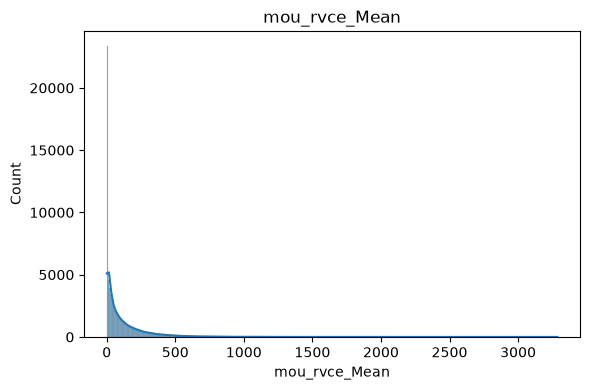

In [14]:
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.tight_layout()
    plt.show()


## uniqsubs column

In [15]:
df['uniqsubs'].describe()

count    100000.000000
mean          1.548140
std           1.075255
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         196.000000
Name: uniqsubs, dtype: float64

In [16]:
df['uniqsubs'].skew()

np.float64(60.519797494375645)

In [17]:
df['uniqsubs'] = np.log(df['uniqsubs'])

In [18]:
df['is_power_user'] = (df['uniqsubs'] > 5).astype(int)
df['is_power_user'].value_counts()

is_power_user
0    99999
1        1
Name: count, dtype: int64

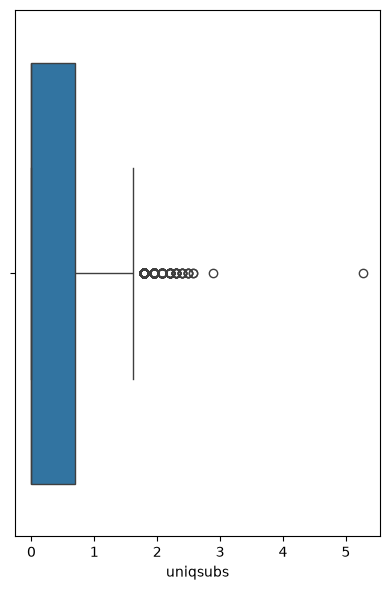

In [19]:
plt.figure(figsize=(4,6))
sns.boxplot(x =df['uniqsubs'])
plt.tight_layout()

## actvsubs column

In [20]:
df['actvsubs'].value_counts()

actvsubs
1     70524
2     24422
3      3776
4       899
5       262
0        81
6        20
8         6
7         5
9         3
53        1
11        1
Name: count, dtype: int64

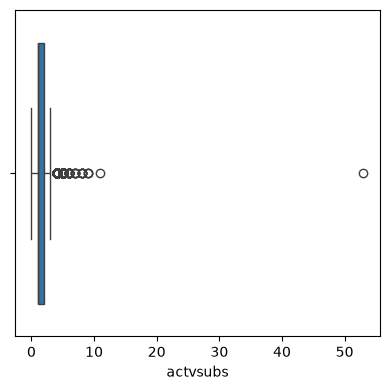

In [21]:
plot_boxplot(df['actvsubs'])


In [22]:
df['actvsubs'].skew()

np.float64(6.867448177482073)

In [23]:
df['actvsubs'].describe()

count    100000.000000
mean          1.358960
std           0.655555
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          53.000000
Name: actvsubs, dtype: float64

In [24]:
df['is_power_actvsubs'] = (df['actvsubs'] > 10).astype(int)
df['actvsubs'] = np.log1p(df['actvsubs'])
df['is_power_actvsubs'].value_counts()

is_power_actvsubs
0    99998
1        2
Name: count, dtype: int64

## new_cell column


In [25]:
df['new_cell'].value_counts()

new_cell
U    66914
Y    19301
N    13785
Name: count, dtype: int64

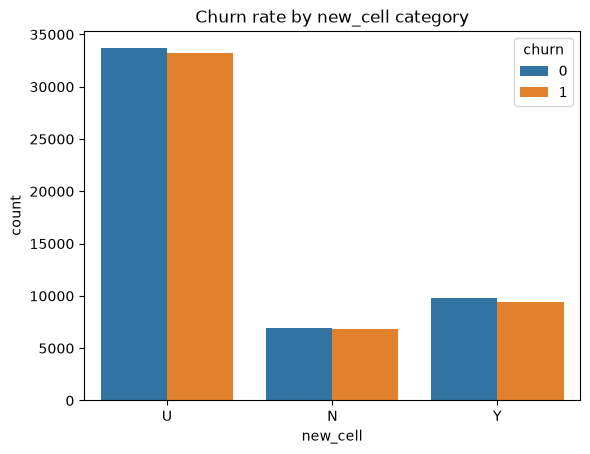

new_cell
N    0.496627
U    0.496951
Y    0.490285
Name: churn, dtype: float64

In [26]:
sns.countplot(x='new_cell', hue='churn', data=df)
plt.title("Churn rate by new_cell category")
plt.show()

# Churn rate per category
df.groupby('new_cell')['churn'].mean()

## crclscod column


In [27]:
df['crclscod'].value_counts()


crclscod
AA    36509
A     16996
BA    12667
CA     8334
EA     6419
B      4110
DA     3669
ZA     3493
C      1456
A2      861
E4      833
U       480
E       339
D4      301
GA      281
Z4      253
D       247
I       243
G       241
JF      194
Z       191
J       190
CY      190
C2      180
M       169
ZY      119
D5      114
B2      109
K       106
W        97
C5       81
V1       70
U1       66
EM       57
Z5       56
Y        54
EC       48
GY       34
CC       25
O        25
E2       21
IF       14
Z1       12
H         9
L         6
P1        6
TP        5
D2        5
Z2        5
EF        4
A3        3
V         1
S         1
ZF        1
Name: count, dtype: int64

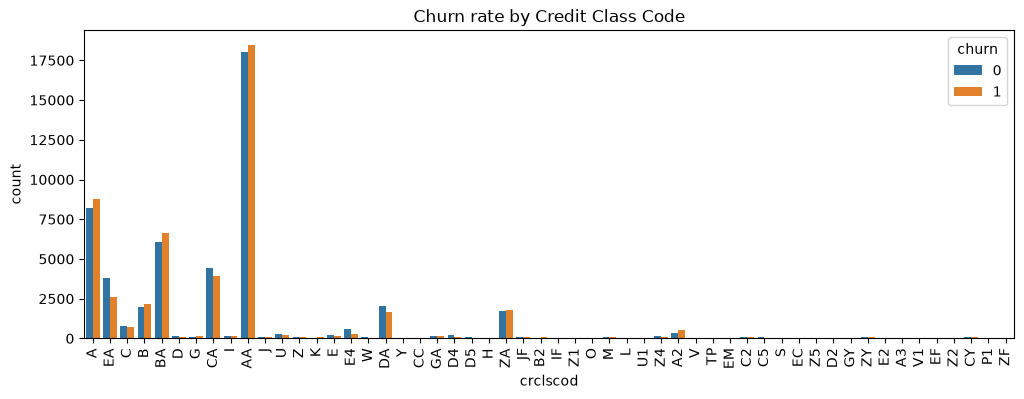

In [28]:
plt.figure(figsize = (12,4))
sns.countplot(x='crclscod', hue='churn', data=df)
plt.xticks(rotation=90)
plt.title("Churn rate by Credit Class Code")
plt.show()

## asl_flag column (Account spending limit)


In [29]:
df['asl_flag'].value_counts()


asl_flag
N    86064
Y    13936
Name: count, dtype: int64

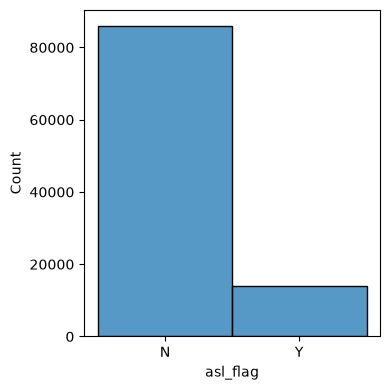

In [30]:
plt.figure(figsize = (4,4))
sns.histplot(df['asl_flag'])
plt.tight_layout()

## totcalls and totmou column


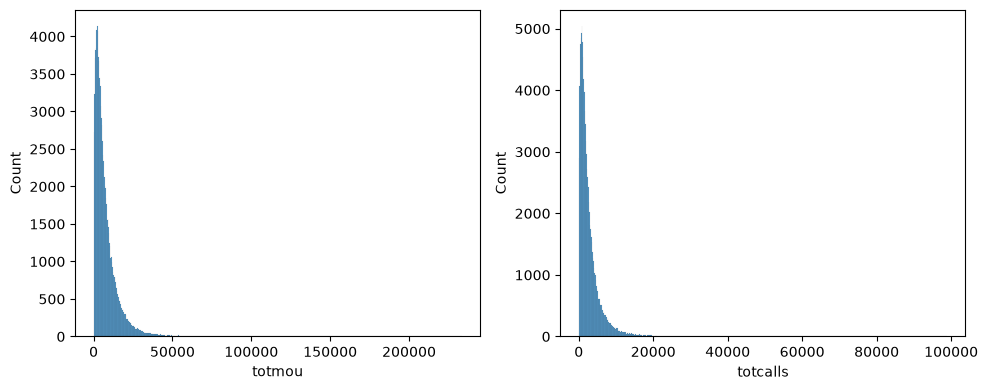

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df['totmou'], ax=axes[0])
sns.histplot(df['totcalls'], ax=axes[1])

plt.tight_layout()

In [32]:
df.groupby('churn')[['totcalls', 'totmou']].mean()


,totcalls,totmou
churn,,
0,2936.439609,7793.975335
1,2816.796174,7500.178673


In [33]:
df[['totcalls', 'totmou']].corr()

,totcalls,totmou
totcalls,1.000000,0.925686
totmou,0.925686,1.000000


## adjrev, totrev and adjqty column


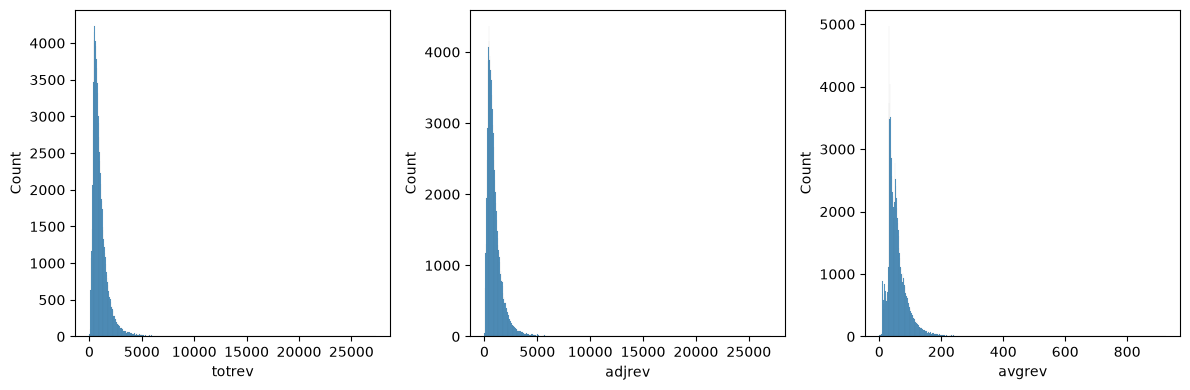

In [34]:
fig ,axes = plt.subplots(1 ,3 , figsize = (12,4))
sns.histplot(df['totrev'] , ax = axes[0])
sns.histplot(df['adjrev'] , ax = axes[1])
sns.histplot(df['avgrev'] , ax = axes[2])


plt.tight_layout()

In [35]:
df[['totrev', 'adjrev', 'avgrev']].corr()

,totrev,adjrev,avgrev
totrev,1.000000,0.998492,0.683362
adjrev,0.998492,1.000000,0.675115
avgrev,0.683362,0.675115,1.000000


## adjmou and avgmou column


<Axes: xlabel='avgmou', ylabel='Count'>

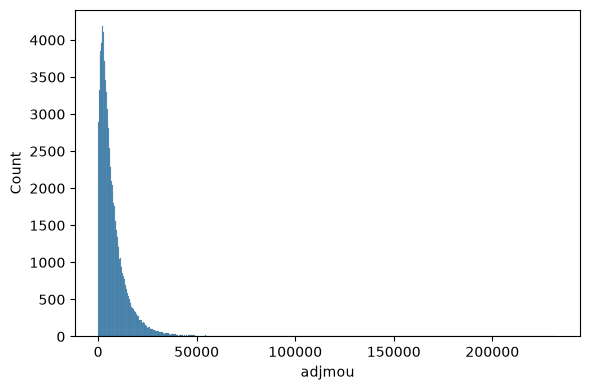

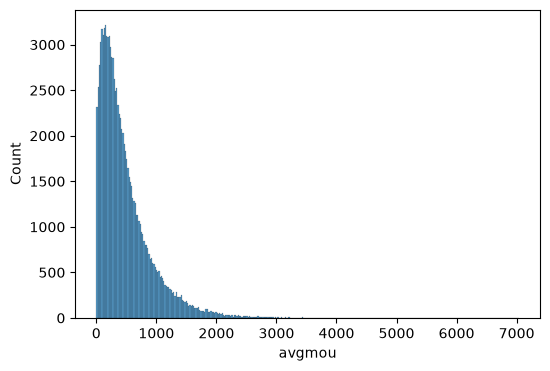

In [36]:
plt.figure(figsize = (6 ,4))
sns.histplot(df['adjmou'])
plt.tight_layout()
plt.figure(figsize = (6 ,4))
sns.histplot(df['avgmou'])

In [37]:
df[['adjmou','avgmou']].corr()

,adjmou,avgmou
adjmou,1.000000,0.720841
avgmou,0.720841,1.000000


## adjqty and avgqty column


<Axes: xlabel='avgqty', ylabel='Count'>

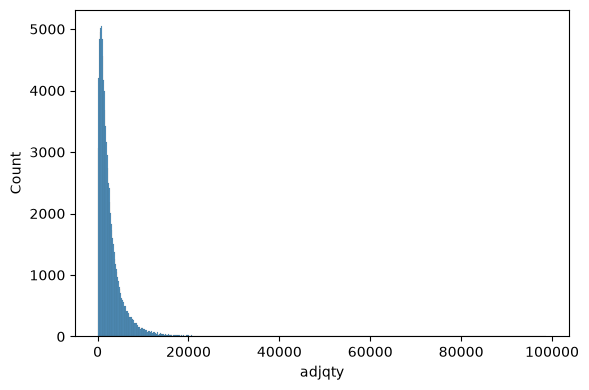

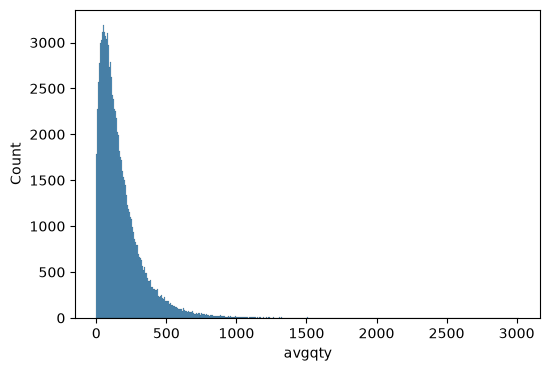

In [38]:
plt.figure(figsize = (6 ,4))
sns.histplot(df['adjqty'])
plt.tight_layout()
plt.figure(figsize = (6 ,4))
sns.histplot(df['avgqty'])

In [39]:
df[['adjmou','avgmou']].corr()

,adjmou,avgmou
adjmou,1.000000,0.720841
avgmou,0.720841,1.000000


# Preprocessing

## new_cell column


In [40]:
#since all three categories has almost same mean so this feature is of no use
#it can be dropped

df.drop(columns = ['new_cell'], inplace = True)

## crclscod column


In [41]:
value_counts = df['crclscod'].value_counts()
rare_categories = value_counts[value_counts < 500].index


df['crclscod'] = df['crclscod'].replace(rare_categories, 'OTHER')


df['crclscod'].value_counts()

#since rare categories are grouped into 'OTHER'


df = pd.get_dummies(df, columns=['crclscod'], drop_first=True)
df

,uniqsubs,actvsubs,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,...,crclscod_AA,crclscod_B,crclscod_BA,crclscod_C,crclscod_CA,crclscod_DA,crclscod_E4,crclscod_EA,crclscod_OTHER,crclscod_ZA
0,0.693147,0.693147,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,...,False,False,False,False,False,False,False,False,False,False
1,0.000000,0.693147,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,...,False,False,False,False,False,False,False,True,False,False
2,0.000000,0.693147,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,...,False,False,False,True,False,False,False,False,False,False
3,0.000000,0.693147,N,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,...,False,True,False,False,False,False,False,False,False,False
4,0.000000,0.693147,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.000000,0.693147,N,3771,9534.00000,1594.83,1561.14,9494.00,3751,74.34,...,False,True,False,False,False,False,False,False,False,False
99996,0.000000,0.693147,Y,3675,8887.00000,1517.10,1451.85,8805.00,3629,72.59,...,False,False,False,False,False,False,False,False,True,False
99997,0.000000,0.693147,N,1271,9336.00000,1114.91,1055.93,9234.00,1238,55.58,...,False,False,False,False,False,True,False,False,False,False
99998,0.000000,0.693147,N,10082,20784.00000,2669.20,2593.26,20488.00,9921,123.49,...,False,False,False,False,False,False,False,True,False,False


## asl_flag column (Account spending limit)


In [42]:
 df = pd.get_dummies(df, columns=['asl_flag'])

## totcalls and totmou column


In [43]:
# since both column are highly correlated so we can drop one

df.drop(columns = ['totmou'], inplace = True)

## totrev, adjrev and avgrev column


In [44]:
# since totrev and adjrev column are highly correlated so we can drop 1

df.drop(columns = ['adjrev'], inplace = True)

In [45]:
df.columns

Index(['uniqsubs', 'actvsubs', 'totcalls', 'totrev', 'adjmou', 'adjqty',
       'avgrev', 'avgmou', 'avgqty', 'churn', 'eqpdays', 'hnd_price',
       'totmrc_Mean', 'mou_Mean', 'mou_cvce_Mean', 'complete_Mean',
       'comp_vce_Mean', 'avg3mou', 'mou_opkv_Mean', 'attempt_Mean',
       'plcd_vce_Mean', 'peak_vce_Mean', 'opk_vce_Mean', 'mou_peav_Mean',
       'mou_rvce_Mean', 'is_power_user', 'is_power_actvsubs', 'crclscod_A2',
       'crclscod_AA', 'crclscod_B', 'crclscod_BA', 'crclscod_C', 'crclscod_CA',
       'crclscod_DA', 'crclscod_E4', 'crclscod_EA', 'crclscod_OTHER',
       'crclscod_ZA', 'asl_flag_N', 'asl_flag_Y'],
      dtype='str')

In [46]:
df.isnull().sum()

uniqsubs               0
actvsubs               0
totcalls               0
totrev                 0
adjmou                 0
adjqty                 0
avgrev                 0
avgmou                 0
avgqty                 0
churn                  0
eqpdays                1
hnd_price            847
totmrc_Mean          357
mou_Mean             357
mou_cvce_Mean          0
complete_Mean          0
comp_vce_Mean          0
avg3mou                0
mou_opkv_Mean          0
attempt_Mean           0
plcd_vce_Mean          0
peak_vce_Mean          0
opk_vce_Mean           0
mou_peav_Mean          0
mou_rvce_Mean          0
is_power_user          0
is_power_actvsubs      0
crclscod_A2            0
crclscod_AA            0
crclscod_B             0
crclscod_BA            0
crclscod_C             0
crclscod_CA            0
crclscod_DA            0
crclscod_E4            0
crclscod_EA            0
crclscod_OTHER         0
crclscod_ZA            0
asl_flag_N             0
asl_flag_Y             0


In [47]:
df.dropna(how='any' , inplace = True)
df.isnull().sum()

uniqsubs             0
actvsubs             0
totcalls             0
totrev               0
adjmou               0
adjqty               0
avgrev               0
avgmou               0
avgqty               0
churn                0
eqpdays              0
hnd_price            0
totmrc_Mean          0
mou_Mean             0
mou_cvce_Mean        0
complete_Mean        0
comp_vce_Mean        0
avg3mou              0
mou_opkv_Mean        0
attempt_Mean         0
plcd_vce_Mean        0
peak_vce_Mean        0
opk_vce_Mean         0
mou_peav_Mean        0
mou_rvce_Mean        0
is_power_user        0
is_power_actvsubs    0
crclscod_A2          0
crclscod_AA          0
crclscod_B           0
crclscod_BA          0
crclscod_C           0
crclscod_CA          0
crclscod_DA          0
crclscod_E4          0
crclscod_EA          0
crclscod_OTHER       0
crclscod_ZA          0
asl_flag_N           0
asl_flag_Y           0
dtype: int64

In [48]:
df.astype(int)

,uniqsubs,actvsubs,totcalls,totrev,adjmou,adjqty,avgrev,avgmou,avgqty,churn,...,crclscod_BA,crclscod_C,crclscod_CA,crclscod_DA,crclscod_E4,crclscod_EA,crclscod_OTHER,crclscod_ZA,asl_flag_N,asl_flag_Y
0,0,0,1652,1504,4085,1602,29,83,32,1,...,0,0,0,0,0,0,0,0,1,0
2,0,0,7903,2155,24303,7888,34,433,140,1,...,0,1,0,0,0,0,0,0,1,0
3,0,0,1502,2000,3035,1479,40,63,30,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,4485,2181,13965,4452,38,249,79,0,...,0,0,0,0,0,0,0,0,1,0
5,0,1,26812,4033,40295,26362,83,857,560,0,...,0,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99984,1,1,1598,1532,7137,1549,70,339,73,1,...,0,0,0,0,0,0,0,0,1,0
99985,0,0,5467,1887,14628,5375,77,636,233,0,...,0,0,0,0,0,0,0,0,1,0
99986,0,0,2686,939,3373,2663,42,160,126,1,...,0,0,0,0,0,1,0,0,1,0
99990,0,0,613,798,2306,598,34,104,27,1,...,0,0,0,0,0,0,0,0,1,0


# Model building


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score , confusion_matrix , f1_score , classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [50]:
X = df.drop('churn' , axis = 1)
y = df['churn']

X_train , X_test , y_train , y_test = train_test_split(X , y ,test_size = 0.20 , random_state =42)

In [51]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

## Models


In [55]:
models ={
    'Logistic Regression': LogisticRegression(),
    'KNN' : KNeighborsClassifier(),
    'Naive Byeas' : GaussianNB(),
    'Decision Tree' : DecisionTreeClassifier(),
     'SVM' : SVC(),
    'Random Forest'       : RandomForestClassifier(n_estimators=100), # ← add
    'XGBoost'             : XGBClassifier()

}

In [56]:
result = []
needs_scaling = ['Logistic Regression', 'KNN', 'SVM']

for name , model in models.items():

    if name in needs_scaling:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    accu = accuracy_score(y_test , y_pred)
    confusion_mat = confusion_matrix(y_test , y_pred)
    f1score = f1_score(y_test , y_pred)
    result.append({
        'Model' : name ,
        'Accuracy': round(accu , 4) ,
        'F1 Score'  : round(f1score , 4) ,
        'confusion_mat': confusion_mat
    })

In [57]:
result

[{'Model': 'Logistic Regression',
  'Accuracy': 0.5742,
  'F1 Score': 0.5683,
  'confusion_mat': array([[5810, 4057],
         [4356, 5537]])},
 {'Model': 'KNN',
  'Accuracy': 0.5496,
  'F1 Score': 0.5399,
  'confusion_mat': array([[5639, 4228],
         [4671, 5222]])},
 {'Model': 'Naive Byeas',
  'Accuracy': 0.5276,
  'F1 Score': 0.6309,
  'confusion_mat': array([[2450, 7417],
         [1917, 7976]])},
 {'Model': 'Decision Tree',
  'Accuracy': 0.5435,
  'F1 Score': 0.5406,
  'confusion_mat': array([[5431, 4436],
         [4585, 5308]])},
 {'Model': 'SVM',
  'Accuracy': 0.5897,
  'F1 Score': 0.5999,
  'confusion_mat': array([[5574, 4293],
         [3815, 6078]])},
 {'Model': 'Random Forest',
  'Accuracy': 0.5998,
  'F1 Score': 0.5974,
  'confusion_mat': array([[5984, 3883],
         [4025, 5868]])},
 {'Model': 'XGBoost',
  'Accuracy': 0.6098,
  'F1 Score': 0.614,
  'confusion_mat': array([[5919, 3948],
         [3762, 6131]])}]